C:\Users\slok0019\AppData\Local\Temp\ipykernel_5696\2156206669.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


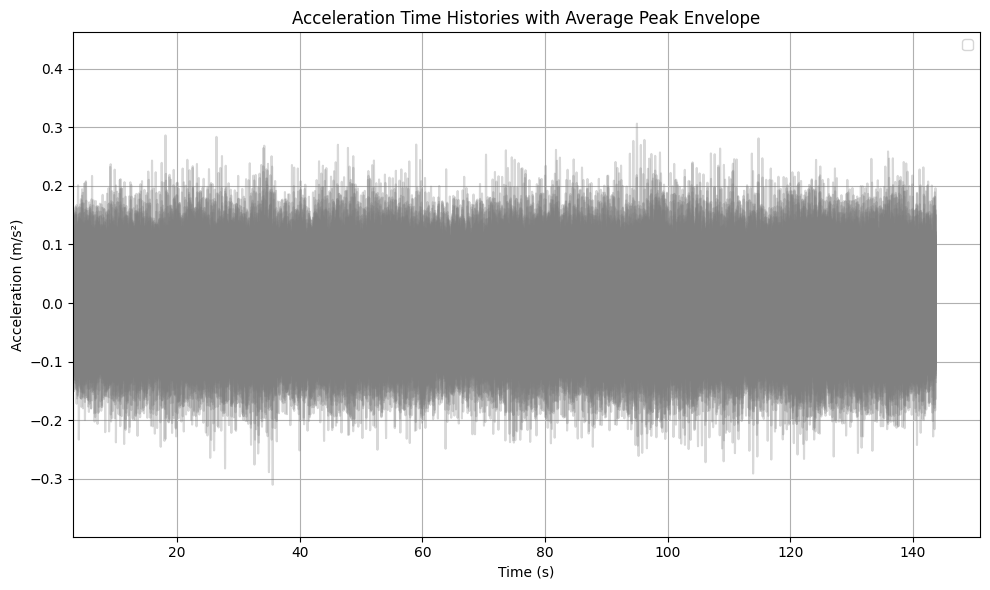

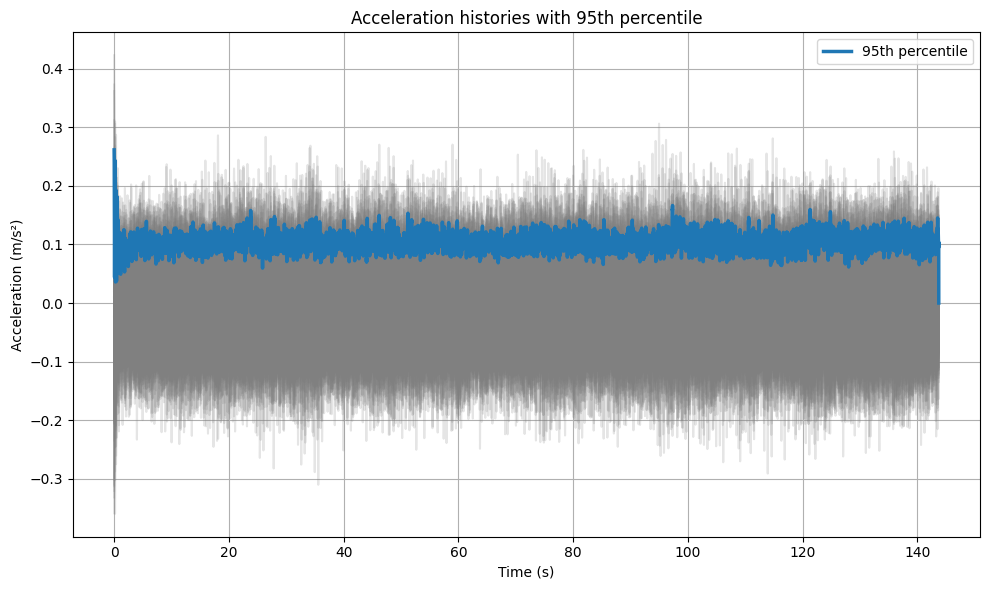

In [ ]:
# --------------------------------------------------
# Time vector for acceleration
# --------------------------------------------------
time = np.arange(accelerations.shape[1]) * hht

# --------------------------------------------------
# Peak envelope for each simulation
# --------------------------------------------------
peak_env = np.zeros_like(accelerations)

for i in range(NUM_SIMULATIONS):
    peak_env[i] = np.maximum.accumulate(np.abs(accelerations[i]))

# Average peak envelope
mean_peak_env = np.mean(peak_env, axis=0)

# --------------------------------------------------
# 1-second RMS
# --------------------------------------------------
window = int(1 / hht)

rms_results = []
for i in range(NUM_SIMULATIONS):
    acc = accelerations[i]
    rms = np.sqrt(np.convolve(acc**2, np.ones(window) / window, mode='valid'))
    rms_results.append(rms)

rms_results = np.array(rms_results)

# Mean RMS across simulations
mean_rms = np.mean(rms_results, axis=0)

# Time vector for RMS ('valid' convolution shortens the length)
time_rms = np.arange(len(mean_rms)) * hht

# --------------------------------------------------
# Plot acceleration histories
# --------------------------------------------------
plt.figure(figsize=(10, 6))

# Individual acceleration histories
for i in range(NUM_SIMULATIONS):
    plt.plot(time, accelerations[i], color='gray', alpha=0.3)

# Mean acceleration
#plt.plot(time, mean_acceleration, color='red', linewidth=2, label='Mean Acceleration')

# Average peak envelope
#plt.plot(time, mean_peak_env, color='blue', linewidth=2, label='Average Peak Envelope')

# 1-sec RMS
#plt.plot(time_rms, mean_rms, color='green', linewidth=2, label='1-sec RMS')

plt.xlabel("Time (s)")
plt.xlim(3,)
plt.ylabel("Acceleration (m/s²)")
plt.title("Acceleration Time Histories with Average Peak Envelope")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 95th percentile acceleration at each time step
acc_95 = np.percentile(accelerations, 95, axis=0)
acc_99 = np.percentile(accelerations, 99, axis=0)
# time vector
time = np.arange(accelerations.shape[1]) * hht

# plot
plt.figure(figsize=(10, 6))

# individual histories
for i in range(NUM_SIMULATIONS):
    plt.plot(time, accelerations[i], color='gray', alpha=0.2)

# 95th percentile curve
plt.plot(time, acc_95, linewidth=2.5, label='95th percentile')

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Acceleration histories with 95th percentile")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

First-order indices S1
pedmass    : 0.2198
pedBodyF   : 0.3967
peddamp    : 0.3335

Total-order indices ST
pedmass    : 0.2290
pedBodyF   : 0.3766
peddamp    : 0.3968

Second-order indices S2
pedmass-pedBodyF : 0.0192
pedmass-peddamp : 0.0302
pedBodyF-peddamp : -0.0278

Acceleration ratio statistics
Mean                = 0.372722
Std. deviation      = 0.080269
Variance            = 0.006443
Coeff. of variation = 0.215359
Median              = 0.364622
5th-95th percentile = [0.259997, 0.513550]
95% interval        = [0.244351, 0.552069]


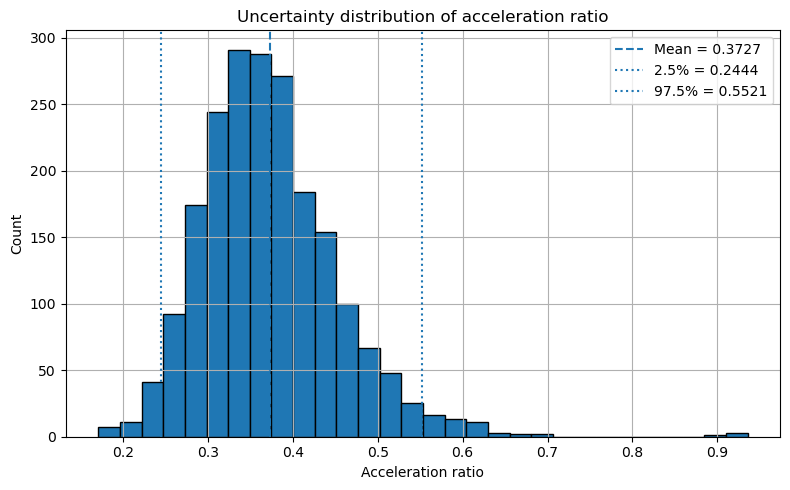

In [3]:
import numpy as np
from scipy.stats import lognorm, truncnorm
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol
from Sensitivity_of_force_factors import run_simulation
from scipy.stats import norm

# -----------------------------
# Fixed bridge case
# -----------------------------
beamFreq = np.array([2.0])   # choose your bridge frequency here
beamdamp = 0.005
length = 50.0
width = 2.0
density = 0.2                # fixed for now

# -----------------------------
# Helper: lognormal parameters from mean and sd
# -----------------------------
def lognormal_mu_sigma(mean, sd):
    sigma2 = np.log(1.0 + (sd**2)/(mean**2))
    sigma = np.sqrt(sigma2)
    mu = np.log(mean) - 0.5 * sigma2
    return mu, sigma

# pedmass ~ lognormal(mean=73, sd=15)
mu_mass, sigma_mass = lognormal_mu_sigma(73.0, 15.0)
dist_mass = lognorm(s=sigma_mass, scale=np.exp(mu_mass))

# pedBodyF ~ truncated normal(mean=3.0, sd=0.2)
dist_f = norm(loc =3.0, scale =0.15)

# peddamp ~ truncated normal(mean=0.28, sd=0.08), truncated to [0.0, 1.0]
mu_d, sd_d = 0.28, 0.08
a_d = (0.0 - mu_d) / sd_d
b_d = np.inf
dist_d = truncnorm(a_d, b_d, loc=mu_d, scale=sd_d)


# -----------------------------
# Sobol problem in unit cube
# -----------------------------
problem = {
    "num_vars": 3,
    "names": ["pedmass", "pedBodyF", "peddamp"],
    "bounds": [[0.0, 1.0], [0.0, 1.0], [0.0, 1.0]],
}

# Base sample size
N = 256   # increase to 512 or 1024 later if needed

# Saltelli/Sobol sample in [0,1]^3
U = sobol_sample.sample(problem, N, calc_second_order=True)

# Transform to target distributions
X = np.zeros_like(U)
X[:, 0] = dist_mass.ppf(U[:, 0])
X[:, 1] = dist_f.ppf(U[:, 1])
X[:, 2] = dist_d.ppf(U[:, 2])

# -----------------------------
# Model evaluation
# -----------------------------
def evaluate_row(row, seed=12345):
    pedmass, pedBodyF, peddamp = row
    return run_simulation(
        (seed, pedmass, peddamp, pedBodyF, beamFreq, beamdamp, density, length, width)
    )

Y = np.array([evaluate_row(row) for row in X], dtype=float)

# -----------------------------
# Sobol analysis
# -----------------------------
Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=False)

print("First-order indices S1")
for name, val in zip(problem["names"], Si["S1"]):
    print(f"{name:10s} : {val:.4f}")

print("\nTotal-order indices ST")
for name, val in zip(problem["names"], Si["ST"]):
    print(f"{name:10s} : {val:.4f}")

print("\nSecond-order indices S2")
for i, name_i in enumerate(problem["names"]):
    for j, name_j in enumerate(problem["names"]):
        if j > i:
            print(f"{name_i}-{name_j} : {Si['S2'][i, j]:.4f}")

Y = np.array([evaluate_row(row) for row in X], dtype=float)

# -----------------------------
# Output mean and uncertainty
# -----------------------------
mean_Y = np.mean(Y)
std_Y  = np.std(Y, ddof=1)          # sample standard deviation
var_Y  = np.var(Y, ddof=1)          # sample variance
cv_Y   = std_Y / mean_Y             # coefficient of variation

q05, q50, q95 = np.percentile(Y, [5, 50, 95])
q025, q975 = np.percentile(Y, [2.5, 97.5])

print("\nAcceleration ratio statistics")
print(f"Mean                = {mean_Y:.6f}")
print(f"Std. deviation      = {std_Y:.6f}")
print(f"Variance            = {var_Y:.6f}")
print(f"Coeff. of variation = {cv_Y:.6f}")
print(f"Median              = {q50:.6f}")
print(f"5th-95th percentile = [{q05:.6f}, {q95:.6f}]")
print(f"95% interval        = [{q025:.6f}, {q975:.6f}]")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(Y, bins=30, edgecolor='black')
plt.axvline(mean_Y, linestyle='--', label=f"Mean = {mean_Y:.4f}")
plt.axvline(q025, linestyle=':', label=f"2.5% = {q025:.4f}")
plt.axvline(q975, linestyle=':', label=f"97.5% = {q975:.4f}")
plt.xlabel("Acceleration ratio")
plt.ylabel("Count")
plt.title("Uncertainty distribution of acceleration ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Running frequency = 1.50 Hz, density = 0.50
Mean = 0.460486
Std  = 0.080520
CV   = 0.174859
S1:
  pedmass   : 0.2007
  pedBodyF  : 0.2420
  peddamp   : 0.5163
ST:
  pedmass   : 0.2144
  pedBodyF  : 0.2748
  peddamp   : 0.5583

Running frequency = 2.00 Hz, density = 0.50
Mean = 0.232365
Std  = 0.057500
CV   = 0.247453
S1:
  pedmass   : 0.1518
  pedBodyF  : 0.3609
  peddamp   : 0.4292
ST:
  pedmass   : 0.1771
  pedBodyF  : 0.3862
  peddamp   : 0.5093

Running frequency = 2.50 Hz, density = 0.50
Mean = 0.107139
Std  = 0.027616
CV   = 0.257763
S1:
  pedmass   : 0.1289
  pedBodyF  : 0.5623
  peddamp   : 0.2186
ST:
  pedmass   : 0.1683
  pedBodyF  : 0.5758
  peddamp   : 0.3236

Running frequency = 3.00 Hz, density = 0.50
Mean = 0.053569
Std  = 0.012326
CV   = 0.230100
S1:
  pedmass   : 0.2144
  pedBodyF  : 0.5396
  peddamp   : 0.1781
ST:
  pedmass   : 0.2808
  pedBodyF  : 0.5174
  peddamp   : 0.2821

Running frequency = 3.50 Hz, density = 0.50
Mean = 0.049573
Std  = 0.012323
CV   = 0.248575

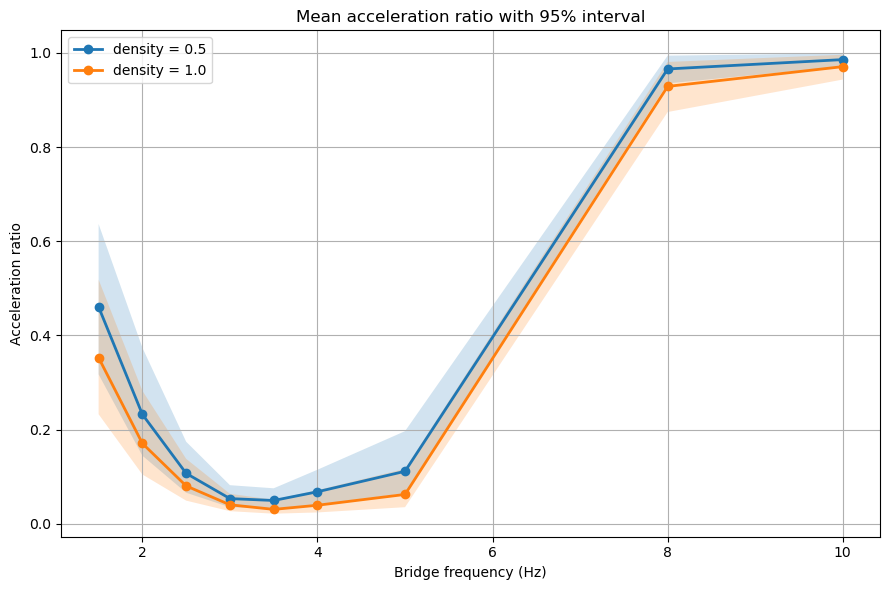

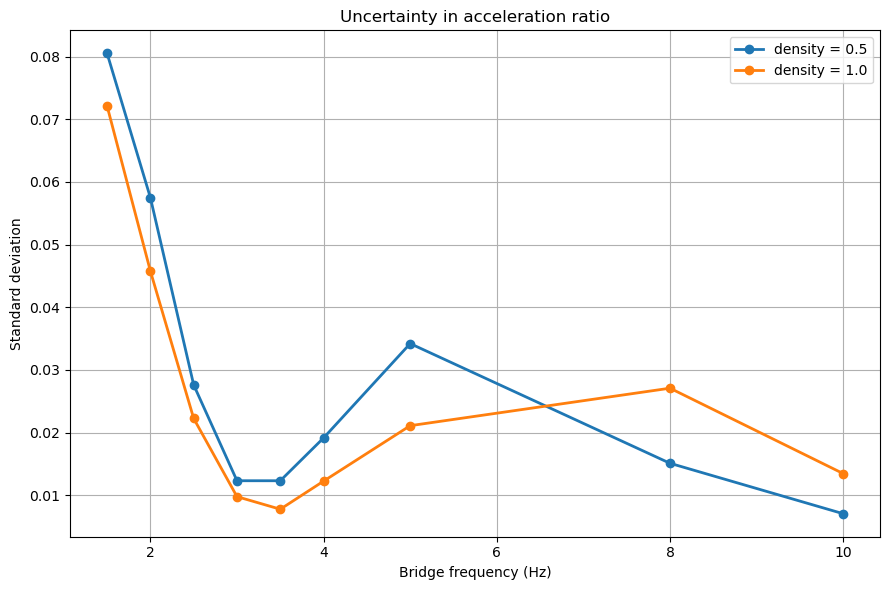

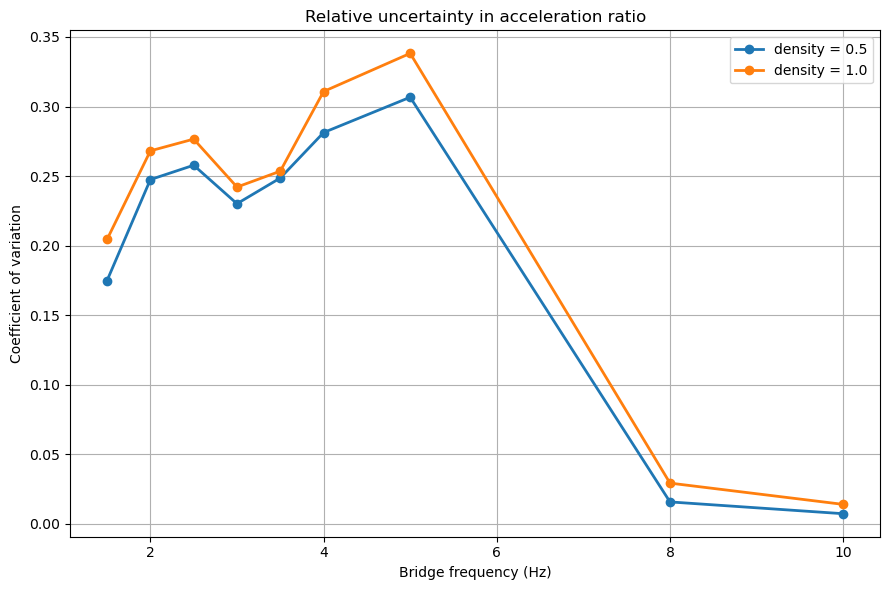

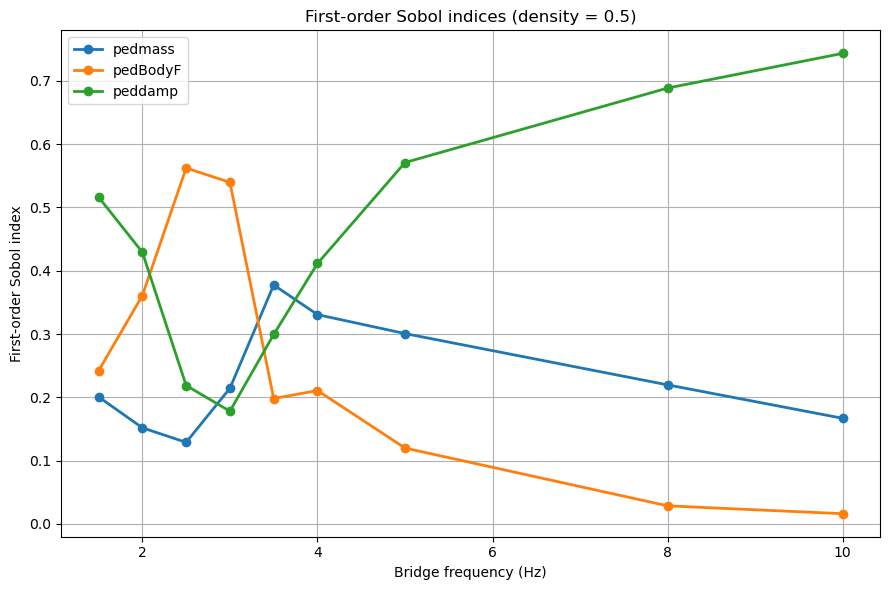

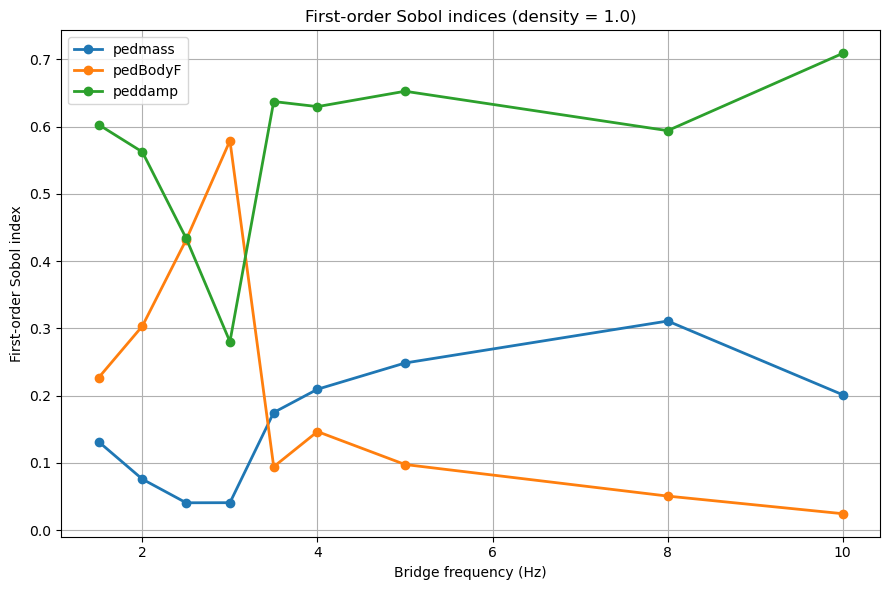

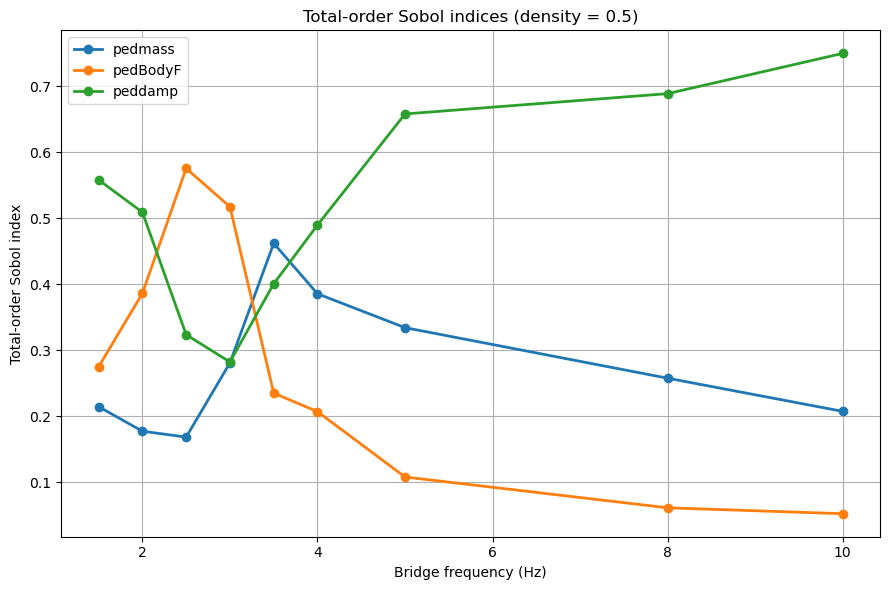

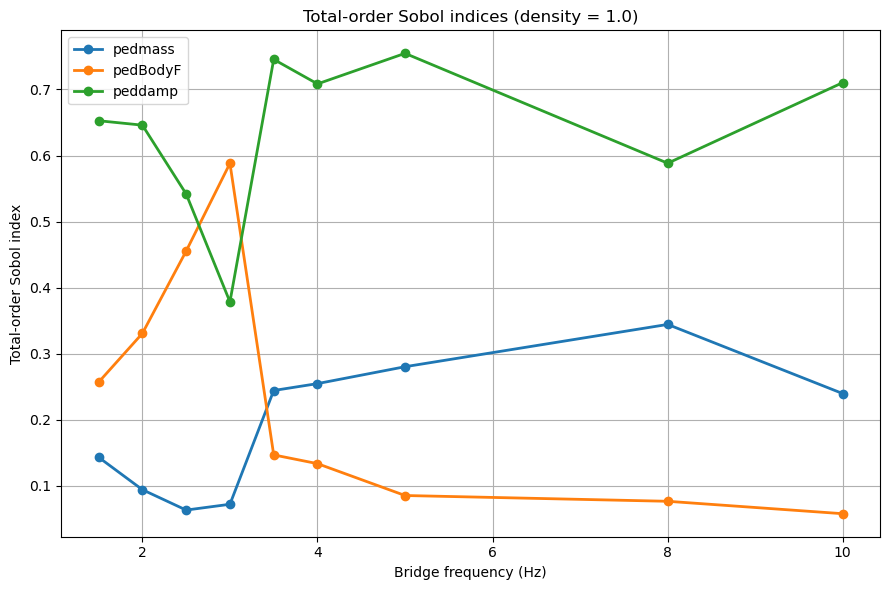

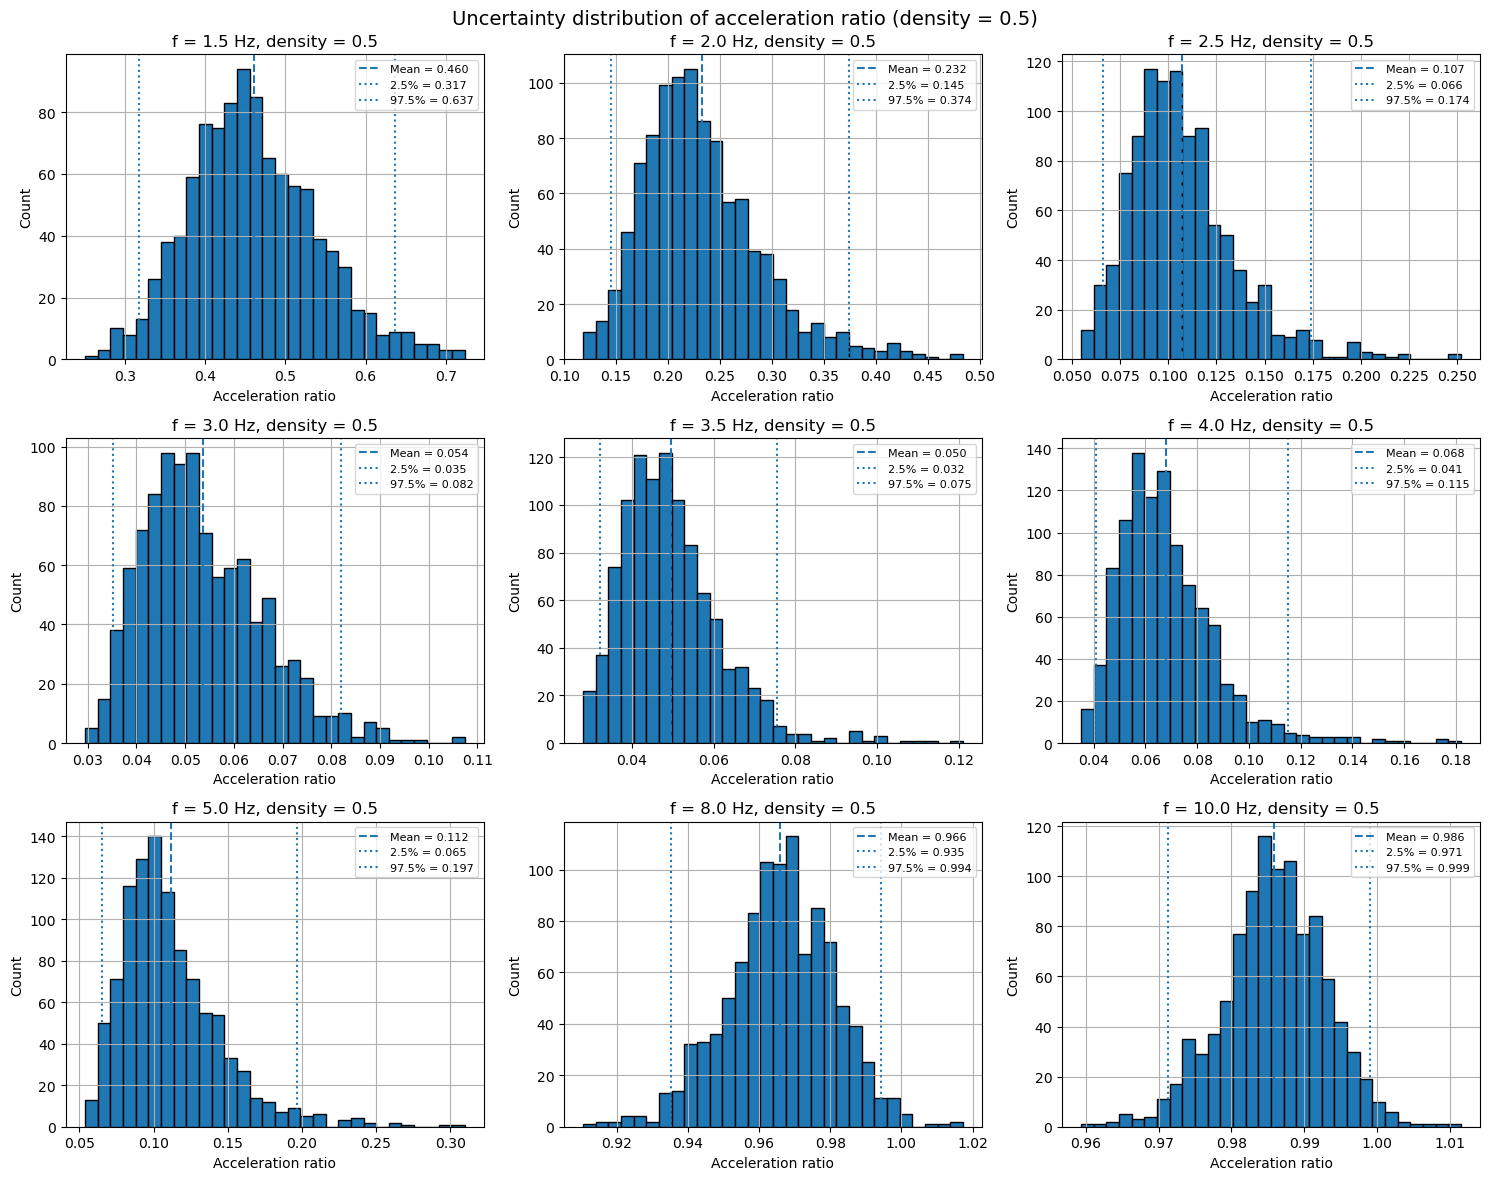

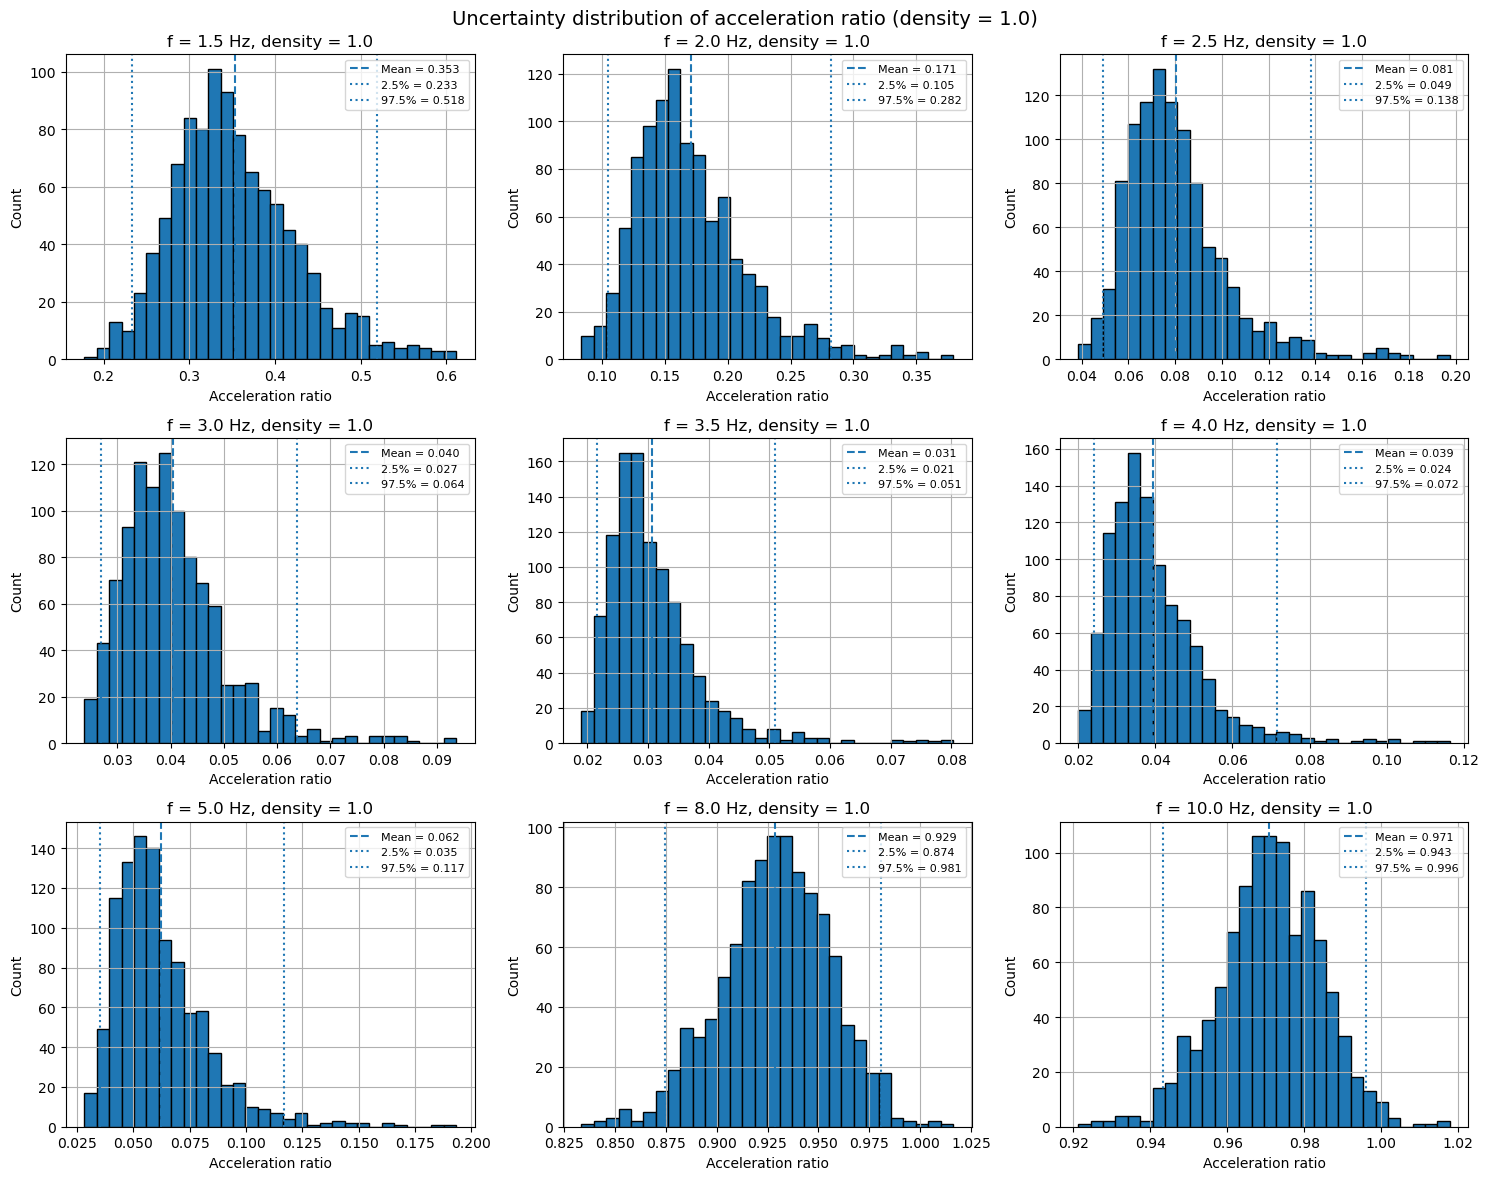

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, truncnorm, norm
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol
from Sensitivity_of_force_factors import run_simulation

# -----------------------------
# Fixed bridge/system constants
# -----------------------------
beamdamp = 0.005
length = 50.0
width = 2.0

bridge_frequencies = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 8.0, 10.0]
densities = [0.5, 1.0]

# -----------------------------
# Helper: lognormal parameters
# -----------------------------
def lognormal_mu_sigma(mean, sd):
    sigma2 = np.log(1.0 + (sd**2) / (mean**2))
    sigma = np.sqrt(sigma2)
    mu = np.log(mean) - 0.5 * sigma2
    return mu, sigma

# -----------------------------
# Input distributions
# -----------------------------
# pedmass ~ lognormal(mean=73, sd=15)
mu_mass, sigma_mass = lognormal_mu_sigma(73.0, 15.0)
dist_mass = lognorm(s=sigma_mass, scale=np.exp(mu_mass))

# pedBodyF ~ normal(mean=3.0, sd=0.15)
dist_f = norm(loc=3.0, scale=0.15)

# peddamp ~ truncated normal(mean=0.28, sd=0.08), truncated to [0, inf)
mu_d, sd_d = 0.28, 0.08
a_d = (0.0 - mu_d) / sd_d
b_d = np.inf
dist_d = truncnorm(a_d, b_d, loc=mu_d, scale=sd_d)

# -----------------------------
# Sobol problem in unit cube
# -----------------------------
problem = {
    "num_vars": 3,
    "names": ["pedmass", "pedBodyF", "peddamp"],
    "bounds": [[0.0, 1.0], [0.0, 1.0], [0.0, 1.0]],
}

# -----------------------------
# Base sample size
# -----------------------------
# For D=3 and calc_second_order=True, total evaluations per case = N * (2D + 2) = 8N
# Start smaller if runtime is heavy
N = 128

# Sobol sample in [0,1]^3
U = sobol_sample.sample(problem, N, calc_second_order=True)

# Clip away from exact 0 and 1 so ppf stays finite
eps = 1e-10
U = np.clip(U, eps, 1.0 - eps)

# Transform to physical distributions
X = np.zeros_like(U)
X[:, 0] = dist_mass.ppf(U[:, 0])
X[:, 1] = dist_f.ppf(U[:, 1])
X[:, 2] = dist_d.ppf(U[:, 2])

# -----------------------------
# Model evaluation
# -----------------------------
def evaluate_row(row, beam_freq, density, seed=12345):
    pedmass, pedBodyF, peddamp = row
    return run_simulation(
        (
            seed,
            pedmass,
            peddamp,
            pedBodyF,
            np.array([beam_freq], dtype=float),
            beamdamp,
            density,
            length,
            width,
        )
    )

# -----------------------------
# Run all cases
# -----------------------------
results_all = {}

for density in densities:
    results_all[density] = {}

    for bf in bridge_frequencies:
        print(f"\nRunning frequency = {bf:.2f} Hz, density = {density:.2f}")

        # Evaluate model on all Sobol samples
        Y = np.array([evaluate_row(row, bf, density) for row in X], dtype=float)

        if not np.all(np.isfinite(Y)):
            raise ValueError(
                f"Non-finite model output found for frequency={bf}, density={density}."
            )

        # Sobol analysis
        Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=False)

        # Output uncertainty stats
        mean_Y = np.mean(Y)
        std_Y = np.std(Y, ddof=1)
        var_Y = np.var(Y, ddof=1)
        cv_Y = std_Y / mean_Y

        q05, q50, q95 = np.percentile(Y, [5, 50, 95])
        q025, q975 = np.percentile(Y, [2.5, 97.5])

        results_all[density][bf] = {
            "Y": Y,
            "mean": mean_Y,
            "std": std_Y,
            "var": var_Y,
            "cv": cv_Y,
            "median": q50,
            "q05": q05,
            "q95": q95,
            "q025": q025,
            "q975": q975,
            "S1": Si["S1"],
            "ST": Si["ST"],
            "S2": Si["S2"],
            "S1_conf": Si["S1_conf"],
            "ST_conf": Si["ST_conf"],
            "names": problem["names"],
        }

        print(f"Mean = {mean_Y:.6f}")
        print(f"Std  = {std_Y:.6f}")
        print(f"CV   = {cv_Y:.6f}")

        print("S1:")
        for name, val in zip(problem["names"], Si["S1"]):
            print(f"  {name:10s}: {val:.4f}")

        print("ST:")
        for name, val in zip(problem["names"], Si["ST"]):
            print(f"  {name:10s}: {val:.4f}")

# -----------------------------
# Print compact summary table
# -----------------------------
print("\n================ SUMMARY ================")
for density in densities:
    print(f"\nDensity = {density}")
    for bf in bridge_frequencies:
        r = results_all[density][bf]
        print(
            f"f = {bf:>4.1f} Hz | "
            f"mean = {r['mean']:.6f} | "
            f"std = {r['std']:.6f} | "
            f"cv = {r['cv']:.6f} | "
            f"95% interval = [{r['q025']:.6f}, {r['q975']:.6f}]"
        )

# -----------------------------
# PLOT 1: Mean with 95% interval
# -----------------------------
plt.figure(figsize=(9, 6))

for density in densities:
    mean_vals = np.array([results_all[density][bf]["mean"] for bf in bridge_frequencies])
    low_vals = np.array([results_all[density][bf]["q025"] for bf in bridge_frequencies])
    high_vals = np.array([results_all[density][bf]["q975"] for bf in bridge_frequencies])

    plt.plot(bridge_frequencies, mean_vals, '-o', linewidth=2, label=f'density = {density}')
    plt.fill_between(bridge_frequencies, low_vals, high_vals, alpha=0.2)

plt.xlabel("Bridge frequency (Hz)")
plt.ylabel("Acceleration ratio")
plt.title("Mean acceleration ratio with 95% interval")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# PLOT 2: Standard deviation vs frequency
# -----------------------------
plt.figure(figsize=(9, 6))

for density in densities:
    std_vals = np.array([results_all[density][bf]["std"] for bf in bridge_frequencies])
    plt.plot(bridge_frequencies, std_vals, '-o', linewidth=2, label=f'density = {density}')

plt.xlabel("Bridge frequency (Hz)")
plt.ylabel("Standard deviation")
plt.title("Uncertainty in acceleration ratio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# PLOT 3: Coefficient of variation vs frequency
# -----------------------------
plt.figure(figsize=(9, 6))

for density in densities:
    cv_vals = np.array([results_all[density][bf]["cv"] for bf in bridge_frequencies])
    plt.plot(bridge_frequencies, cv_vals, '-o', linewidth=2, label=f'density = {density}')

plt.xlabel("Bridge frequency (Hz)")
plt.ylabel("Coefficient of variation")
plt.title("Relative uncertainty in acceleration ratio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# PLOT 4: First-order Sobol indices
# -----------------------------
for density in densities:
    plt.figure(figsize=(9, 6))

    for k, name in enumerate(problem["names"]):
        s1_vals = np.array([results_all[density][bf]["S1"][k] for bf in bridge_frequencies])
        plt.plot(bridge_frequencies, s1_vals, '-o', linewidth=2, label=name)

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("First-order Sobol index")
    plt.title(f"First-order Sobol indices (density = {density})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------
# PLOT 5: Total-order Sobol indices
# -----------------------------
for density in densities:
    plt.figure(figsize=(9, 6))

    for k, name in enumerate(problem["names"]):
        st_vals = np.array([results_all[density][bf]["ST"][k] for bf in bridge_frequencies])
        plt.plot(bridge_frequencies, st_vals, '-o', linewidth=2, label=name)

    plt.xlabel("Bridge frequency (Hz)")
    plt.ylabel("Total-order Sobol index")
    plt.title(f"Total-order Sobol indices (density = {density})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

for density in densities:
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for i, bf in enumerate(bridge_frequencies):
        ax = axes[i]

        r = results_all[density][bf]
        Y = r["Y"]
        mean_Y = r["mean"]
        q025 = r["q025"]
        q975 = r["q975"]

        ax.hist(Y, bins=30, edgecolor='black')
        ax.axvline(mean_Y, linestyle='--', label=f"Mean = {mean_Y:.3f}")
        ax.axvline(q025, linestyle=':', label=f"2.5% = {q025:.3f}")
        ax.axvline(q975, linestyle=':', label=f"97.5% = {q975:.3f}")

        ax.set_title(f"f = {bf} Hz, density = {density}")
        ax.set_xlabel("Acceleration ratio")
        ax.set_ylabel("Count")
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.suptitle(f"Uncertainty distribution of acceleration ratio (density = {density})", fontsize=14)
    plt.tight_layout()
    plt.show()